<a href="https://colab.research.google.com/github/harjasjolly-create/algorithmic-stock-rating-program/blob/main/hypothesis_verifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import yfinance as yf
import pandas as pd
data = yf.download("AAPL", period="54wk", interval="1wk")
import seaborn as sns
import numpy as np

/tmp/ipykernel_587/2456577859.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", period="54wk", interval="1wk")
[*********************100%***********************]  1 of 1 completed


In [7]:
df=pd.DataFrame(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 55 entries, 2025-08-04 to 2026-08-17
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   55 non-null     float64
 1   (High, AAPL)    55 non-null     float64
 2   (Low, AAPL)     55 non-null     float64
 3   (Open, AAPL)    55 non-null     float64
 4   (Volume, AAPL)  55 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 2.6 KB


**BUILDING CHART_ANALYSIS MODEL **

In [8]:
close,high,low,open,volume=df.iloc[:,0],df.iloc[:,1],df.iloc[:,2],df.iloc[:,3],df.iloc[:,4]


**creating simple moving average(sma)** somewhat an average position vector but of closing prices(average closing value fo a batch

In [9]:
sma=close.rolling(window=20).mean()#taking batch of 20 weeks at a time, shifting by 1
sma.head()


,Close
,AAPL
Date,
2025-08-04,NaN
2025-08-11,NaN
2025-08-18,NaN
2025-08-25,NaN
2025-09-01,NaN


[Text(0.5, 0, 'Time'), Text(0, 0.5, 'SMA')]

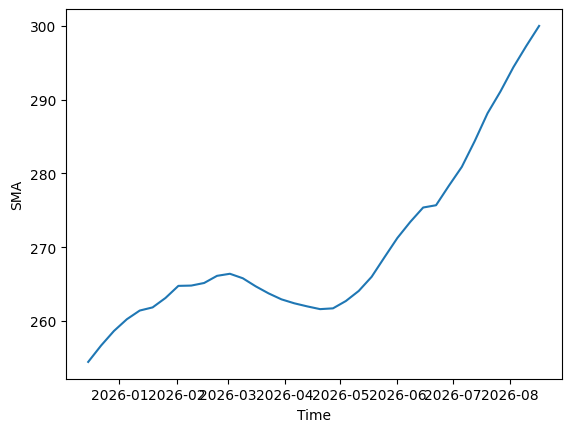

In [10]:
#visualizing sma
sns.lineplot(sma.dropna()).set(xlabel='Time',ylabel='SMA')


creating the sma score with assuming stock price> sma is uptrend and including a 5%zone as nopise clearance so stock distance fro. sdma>5%sma will be considered uptredn so a +1 score(similar logic for-1,0)

In [11]:
stock_distance=(close-sma)/sma
conditions=[(stock_distance>0.05),(stock_distance<-0.05)]
choices=[1,-1]
sma_score=np.select(conditions,choices,default=0)




**creating average true range(14 candle) (ATR14)**

In [12]:
from os import name
tr1=high-low
#now we need prev timeframe's close value
close_prev=close.shift(1)#since we need prev week closing
tr2=(high-close_prev).abs()
tr3=(low-close_prev).abs()
values=pd.concat([tr1,tr2,tr3],axis=1)
tr_final=values.max(axis=1)
atr14=tr_final.rolling(window=14).mean()
atr14.rename('ATR14',inplace=True)

atr14.head()#so basically average max volatility over 14cweeks batches

,ATR14
Date,
2025-08-04,NaN
2025-08-11,NaN
2025-08-18,NaN
2025-08-25,NaN
2025-09-01,NaN


**EMA**

Building ema so as to incorporate recent trends more weighted than past trends , for better accuracy, ill be using ema20 and ema50 with assumption that ema20 moving faaster than ema 50 means bullish trend

In [13]:
ema20=close.ewm(span=20,adjust=False).mean()
ema50=close.ewm(span=50,adjust=False).mean()#weight decreases as day goes more in past
ema_signal=(ema20-ema50)/close#dividing by closing price so as to create a ratio relative to stock price for better classification model training across different stocks
ema_signal.head()


,Close
,AAPL
Date,
2025-08-04,0.000000
2025-08-11,0.000605
2025-08-18,0.000205
2025-08-25,0.000908
2025-09-01,0.003236


[Text(0.5, 0, 'Time'), Text(0, 0.5, 'EMA')]

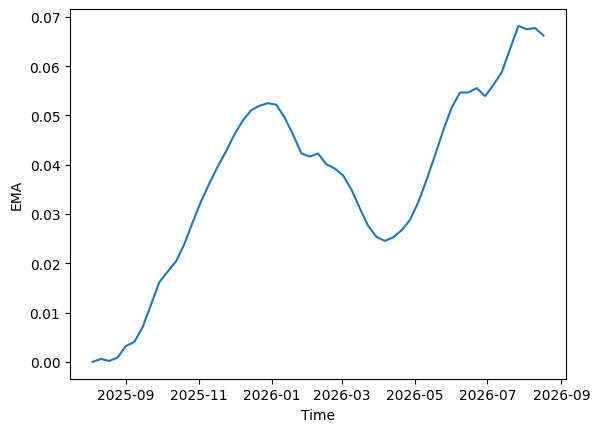

In [14]:
sns.lineplot(ema_signal).set(xlabel='Time',ylabel='EMA')

Finding **Optimal thresholds** for finding ema_signal_score using its **standard deviation**
using the threshold as  **mean+-0.5*std**

In [15]:

upper_threshold=ema_signal.mean()+0.5*ema_signal.std()
lower_threshold=ema_signal.mean()-0.5*ema_signal.std()
conditions=[(ema_signal>upper_threshold) , (ema_signal<lower_threshold)]
choices=[1,-1]
ema_signal_score=np.select(conditions,choices,default=0)
ema_signal_score



array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,  0,  0,
        0,  1,  1,  1,  1,  1,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
       -1, -1, -1, -1,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1])

**Building RSI i.e relative strength of buyers to sellers**, cosidering rsi>50 as bullish,<50 as bearish ,>70 as overbought,<30 as oversold , basically it tells what poercentage of price movements is bullish

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1,
       -1, -1, -1, -1,  1,  1,  1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1,  1,  1,  1,  1, -1, -1, -1,  1, -1,  1, -1, -1, -1, -1,
        1,  1,  1,  1])

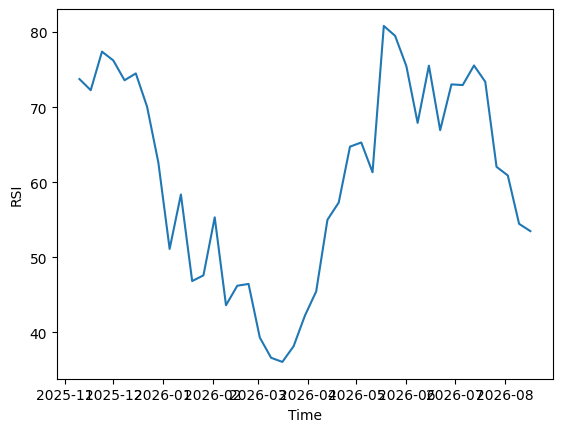

In [16]:
delta=close.diff()# calculating price change
gain=delta.clip(lower=0).rolling(14).mean()
loss=-delta.clip(upper=0).rolling(14).mean()
rs=gain/loss
#normalising rs from 0 ro 100 instead of 0 to infinity
rsi=100-100/(1+rs)
#giving the rsi score

conditions = [
    (rsi > 70), # overbought
    (rsi < 30), # oversold
    (rsi >= 50) & (rsi <= 70), # bullish
    (rsi >= 30) & (rsi < 50) # bearish
]
choices = [-1, 1, 1, -1]
rsi_score = np.select(conditions, choices, default=0)

sns.lineplot(rsi).set(xlabel='Time',ylabel='RSI')
rsi_score


note: each rolling code requires actual entires so initial and final value might be considered nan output, as im currently using 54 week data, we can increase it to create a better model

**Building support resistance levels**

firstly, building swing highs and swing lows thats local highs and lows over 7 week windows

In [17]:
df["is_swing_high"]=(high==high.rolling(7,center=True).max())
df["is_swing_low"]=(low==low.rolling(7,center=True).min())
swing_high=df.loc[df['is_swing_high'],('High','AAPL')]
swing_low=df.loc[df["is_swing_low"],('Low','AAPL')]


now, we need to cluster swing highs and lows that are almost nearby so as to create the support and resistance levels but the zone width to consider two lows in same cluster is dependent on the volatility of stock  so well use atr for this ans assume a safe zone width of atr*0.5 so the lows can be within 50% of volatility at that time and hence considered the same lows and if 2 lows fall into a cluster, then that will be the support

In [18]:
atr_multiplier=0.5

In [19]:
support_df=pd.concat([swing_low,atr14],axis=1).dropna()
support_df


,"(Low, AAPL)",ATR14
Date,,
2026-01-19,242.759215,10.319512
2026-03-30,245.072652,13.001511
2026-06-22,273.514106,15.877309
2026-07-27,299.741503,20.161275


In [20]:
#converting to list of dictionaries so that i can pop without any index error and also itll increase speed as dataframes are slow in delecting rows and looping over them (though they are fast at simukltaneous math)
swinglows=support_df.to_dict('records')#using record so that it created dictionary liost row wise and not column wise(record and row are same things)
swinglows


[{('Low', 'AAPL'): 242.75921493368202, 'ATR14': 10.319511502141347},
 {('Low', 'AAPL'): 245.07265167866177, 'ATR14': 13.001510856893066},
 {('Low', 'AAPL'): 273.51410564235374, 'ATR14': 15.877309275574545},
 {('Low', 'AAPL'): 299.7415030462749, 'ATR14': 20.161274901141393}]

In [21]:
true_support=[]
while len(swinglows)>0:
  base_item = swinglows.pop(0)
  base_price = base_item[('Low', 'AAPL')]
  base_atr = base_item['ATR14']
  zone_width=atr_multiplier*base_atr
  potential_support=[base_price]
  remaining=[]
  for rest in swinglows:
    if abs(rest[('Low', 'AAPL')]-base_price)<=zone_width:
      potential_support.append(rest[('Low', 'AAPL')])
    else:
      remaining.append(rest)
  swinglows=remaining
  if len(potential_support)>=2:
    avg_support=sum(potential_support)/len(potential_support)
    true_support.append(avg_support)


In [22]:
true_support

[243.9159333061719]

In [23]:
#now coding true_resistance

In [24]:
resistance_df=pd.concat([swing_high,atr14],axis=1).dropna()
resistance_df

,"(High, AAPL)",ATR14
Date,,
2025-12-01,287.836509,11.305382
2026-02-02,280.147425,10.899128
2026-06-08,317.126504,14.625509
2026-07-27,344.273106,20.161275


In [25]:
swinghighs=resistance_df.to_dict('records')
true_resistance=[]
while len(swinghighs)>0:
  top_item = swinghighs.pop(0)
  top_price = top_item[('High', 'AAPL')]
  top_atr = top_item['ATR14']
  zone_width=atr_multiplier*top_atr
  potential_resistance=[top_price]
  remaining=[]
  for rest in swinghighs:
    if abs(rest[('High', 'AAPL')]-top_price)<=zone_width:
      potential_resistance.append(rest[('High', 'AAPL')])
    else:
      remaining.append(rest)
  swinghighs=remaining
  if len(potential_resistance)>=2:

    avg_resistance=sum(potential_resistance)/len(potential_resistance)
    true_resistance.append(avg_resistance)




In [26]:
true_resistance

[]

**finding the triple barrier score and alpha_score**





In [27]:
# ill be using triple barrier method for stock_execution score and alpha for stock_alpha score so as to check strength relative to benchmark
#ill use s&p 500 returns as benchmark


**triple barrier**

In [28]:

stock_data=pd.concat([close,atr14],axis=1)
#using name upper amnd lower barrier instead of target and stop loss so as to justify the name triple barrier;)

In [29]:
stock_data['upper_barrier']=stock_data[('Close', 'AAPL')]+stock_data['ATR14']*2
stock_data['lower_barrier']=stock_data[('Close', 'AAPL')]-stock_data['ATR14']*1
stock_data.sample(5)

,"(Close, AAPL)",ATR14,upper_barrier,lower_barrier
Date,,,,
2026-06-22,283.535461,15.877309,315.290080,267.658152
2026-02-02,277.364990,10.899128,299.163245,266.465863
2026-08-10,305.929993,19.123559,344.177111,286.806433
2026-03-23,248.356796,12.658873,273.674542,235.697923
2026-05-25,311.791107,13.442002,338.675111,298.349105


In [30]:
#lets use time barrier of 2 weeks
stock_data["shifted_close"]=stock_data[('Close', 'AAPL')].shift(-2)



In [31]:
#now giving score of +1,-1 and 0 accordingly
import numpy as np
conditions=[(stock_data["shifted_close"]>=stock_data['upper_barrier']),(stock_data["shifted_close"]<=stock_data['lower_barrier'])]
choices=[1,-1]
stock_data["exec_score"]=np.select(conditions,choices,default=0)
stock_data.tail(5)


,"(Close, AAPL)",ATR14,upper_barrier,lower_barrier,shifted_close,exec_score
Date,,,,,,
2026-07-20,332.733032,17.719840,368.172713,315.013192,313.059998,-1
2026-07-27,308.643829,20.161275,348.966379,288.482554,305.929993,0
2026-08-03,313.059998,19.650315,352.360628,293.409682,310.029999,0
2026-08-10,305.929993,19.123559,344.177111,286.806433,NaN,0
2026-08-17,310.029999,18.808642,347.647284,291.221356,NaN,0


**now the benchmark comparison that is alpha score**

In [32]:
snp_data=yf.download("^GSPC",period="54wk",interval="1wk")
snp_close=pd.DataFrame(snp_data).iloc[:,0]
snp_close.info()

/tmp/ipykernel_587/520086488.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  snp_data=yf.download("^GSPC",period="54wk",interval="1wk")
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.series.Series'>
DatetimeIndex: 55 entries, 2025-08-04 to 2026-08-17
Series name: ('Close', '^GSPC')
Non-Null Count  Dtype  
--------------  -----  
55 non-null     float64
dtypes: float64(1)
memory usage: 880.0 bytes


In [33]:
#now comparison
#ill be using 2 week timeframe for return comparison
stock_data['stock_return_2wk']=(stock_data['shifted_close']-stock_data[('Close', 'AAPL')])/stock_data[('Close', 'AAPL')]
snp_data['shifted_close']=snp_close.shift(-2)
stock_data['snp_return_2wk']=(snp_data['shifted_close']-snp_data[('Close', '^GSPC')])/snp_data[('Close', '^GSPC')]
stock_data['aplha']=stock_data['stock_return_2wk']-stock_data['snp_return_2wk']
#considering a buffer oif 0.5% so as to remove buffer as if alpha is 0.2% more than benchmark, it isnt really a great winner but similiar to 0 so just a noise so well consider it as 0
conditions=[(stock_data['aplha']>0.005),stock_data['aplha']<0.005]
choices=[1,-1]
stock_data["alpha_score"]=np.select(conditions,choices,default=0)
stock_data['alpha_score'].head()

,alpha_score
Date,
2025-08-04,-1
2025-08-11,-1
2025-08-18,1
2025-08-25,-1
2025-09-01,-1


**now creating a score based on support resitance , considering if close is within 1%of nearest support or resistance, then well consider the actual +-1 score else iot wopnt really matter and hence 0**


In [34]:
#true_support
#true_resistance
#finding closest resistance and support

def find_nearest_support(value):
  if not true_support:
    return np.nan
  min_dist=(abs(true_support[0]-value))
  nearest_support=true_support[0]
  for i in true_support:
    if abs(i-value)<=min_dist:
      min_dist=abs(i-value)
      nearest_support=i
  return nearest_support
def find_nearest_resistance(value):
  if not true_resistance:
    return np.nan
  min_dist=(abs(true_resistance[0]-value))
  nearest_resistance=true_resistance[0]
  for i in true_resistance:
    if abs(i-value)<=min_dist:
      min_dist=abs(i-value)
      nearest_resistance=i
  return nearest_resistance
stock_data["nearest resistance"]=0
stock_data["nearest support"]=0
stock_data["nearest resistance"]=stock_data[('Close', 'AAPL')].apply(find_nearest_resistance)
stock_data["nearest support"]=stock_data[('Close', 'AAPL')].apply(find_nearest_support)





In [35]:
#now if stock is in 1% zone of nearest support that would mean upside potential so floor_ceiling_score=+1 and -1 for similar with nearest resistance else 0
conditions=[(abs(stock_data[('Close', 'AAPL')]-stock_data['nearest support'])/stock_data['nearest support']<=0.01),(abs(stock_data[('Close', 'AAPL')]-stock_data['nearest resistance'])/stock_data['nearest resistance']<=0.01)]
choices=[+1,-1]
stock_data['floor_ceiling_score']=np.select(conditions,choices,default=0)
stock_data['floor_ceiling_score'].sample(5)


,floor_ceiling_score
Date,
2026-05-25,0
2026-03-23,0
2026-07-20,0
2025-10-20,0
2026-04-06,0


**adding the earlier calculated rsi_score and ema_signal_score and sma _score**

In [36]:
stock_data['RSI Score']=rsi_score
stock_data["EMA Signal Score"]=ema_signal_score
stock_data["SMA Score"]=sma_score



In [37]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 55 entries, 2025-08-04 to 2026-08-17
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, AAPL)        55 non-null     float64
 1   ATR14                42 non-null     float64
 2   upper_barrier        42 non-null     float64
 3   lower_barrier        42 non-null     float64
 4   shifted_close        53 non-null     float64
 5   exec_score           55 non-null     int64  
 6   stock_return_2wk     53 non-null     float64
 7   snp_return_2wk       53 non-null     float64
 8   aplha                53 non-null     float64
 9   alpha_score          55 non-null     int64  
 10  nearest resistance   0 non-null      float64
 11  nearest support      55 non-null     float64
 12  floor_ceiling_score  55 non-null     int64  
 13  RSI Score            55 non-null     int64  
 14  EMA Signal Score     55 non-null     int64  
 15  SMA Score            5

getting company fundamnetaks form yahoo finance as earlier ome thats stockanaysis stopped me because of some cloudware wall stuff, basically they are not letting me scrape the data;(

In [38]:
def get_fundamentals(ticker_symbol):
    stock = yf.Ticker(ticker_symbol)
    data = stock.info

    fundamentals = {
        'PE_Ratio': data.get('trailingPE', 0),
        'Forward_PE': data.get('forwardPE', 0),




        'PEG_Ratio': data.get('trailingPegRatio', data.get('pegRatio', 0)),


        'ROE': data.get('returnOnEquity', 0),



        'Price_to_Book': data.get('priceToBook', 0),
        'Revenue_Growth_YoY': data.get('revenueGrowth', 0),
        'Earnings_Growth_YoY': data.get('earningsGrowth', 0),
        'Profit_Margin': data.get('profitMargins', 0),
        'Debt_to_Equity': data.get('debtToEquity', 0)
    }

    return fundamentals


metrics = get_fundamentals("AAPL")
print(f"PE Ratio: {metrics['PE_Ratio']}")
print(f"PEG Ratio: {metrics['PEG_Ratio']}")
print(f"Return on Equity: {metrics['ROE'] * 100}%")
print(f"Debt to Equity: {metrics['Debt_to_Equity']/100}")
de_ratio=metrics['Debt_to_Equity']/100
roe=metrics['ROE']*100
peg_ratio=metrics['PEG_Ratio']
pe_ratio=metrics['PE_Ratio']


PE Ratio: 35.59472
PEG Ratio: 2.464
Return on Equity: 148.75101%
Debt to Equity: 0.78445


**pe score** currently setting thresholds but will use avg pe_ratio of past years to get the relative score which is more accurate but will do that later on as im getting this year data alone, ill try finding eps of past years and then divide by that years stock price to get the pe_ratios of those years

In [39]:

conditions=[(pe_ratio<=25),(25<pe_ratio<=30),(pe_ratio>30)]
choices=[1,0,-1]
pe_score=np.select(conditions,choices,default=0)
pe_score


array(-1)

**now finding peg score**

In [40]:

if peg_ratio<1:
  peg_score=1
elif 1<peg_ratio<2:
  peg_score=0
else:
  peg_score=-1
#used standard threshold for peg overvalued or undervalued
print(peg_score)


-1


**roe score using standard roe>20% roe<10% criteria**

In [41]:
if roe>=20:
  roe_score=+1
elif roe<=10:
  roe_score=-1
else:
  roe_score=0
roe_score


1

**debt/equity score using d/e<0.5 as safe adn d/e>1.5 as unsafe and in between moderate**

In [42]:
if de_ratio<=0.5:
  de_score=+1
elif de_ratio>=1.5:
  de_score=-1
else:
  de_score=0
de_score

0

for now i am averaging these scores to get **avg_fundamental_score**
we can later add optimal weights to each score if needeed but presently imassuming all to be equally important
---



In [43]:
avg_fundamental_score=(pe_score+peg_score+de_score+roe_score)/4

temp_data=stock_data
avg_fundamental_score

np.float64(-0.25)

**now calculating sentiment score taht is basically score based on news headlines**

In [44]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00


In [45]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer=SentimentIntensityAnalyzer()
from bs4 import BeautifulSoup
import requests
headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/89.0.43)'}
web=requests.get('https://finance.yahoo.com/quote/AAPL/$0',headers=headers).text
response=BeautifulSoup(web,'lxml')
news=response.find_all('h3',class_='clamp yf-28d2hc')
news_list=[i.text for i in news]
news_list

['Wall Street clearly loves Google stock, 13F filings reveal',
 'Apple Cuts EU App Fees to 5% Outside the App Store',
 'Apple Changes App Store Terms to Resolve E.U. Antitrust Dispute',
 'Apple Overhauls EU App Store Policies to Settle Long-Standing Antitrust Dispute',
 'Apple overhauls its EU App Store fees, loosens rules for alternative app stores',
 'Apple changes fees for alternative app stores in EU',
 'Nvidia Stock Drops In Broad Market Slide With Earnings In Sight. Is Nvidia A Buy Or Sell Now?',
 "Can Qualcomm's Advanced Snapdragon Mobile Portfolio Boost Profits?",
 'How Sonos Q4 Guidance Balances Revenue Growth Against Memory Inflation',
 "Apple's Foldable Could Lift iPhone Prices 11%, Redburn Says",
 '5 Dividend Growth ETFs to Buy']

In [46]:
news_score_list=[]
for item in news_list:
  news_score=analyzer.polarity_scores(item)['compound']#just got to kniow that this gives 4 oparameters, neutral,negatuve,positive and theuir overall avg thats compoiund in -1 to 1 range
  news_score_list.append(news_score)
sentiment_score=np.mean(news_score_list)
sentiment_score


np.float64(0.1414090909090909)

#presently i am using normal average on news scores but technically i should have used exponenytisl average as recent news matter more but i will see that later for better model

In [47]:
#now some chart_score logic

we have:


1. sentiment_score
2. fundamental_score



---


now finally i'll build the **chart_score **which will be based on applying optimal weights using **LogisticRegression** on 6 scores:



1.   rsi_score
2.   ema_signal_score
3.   sma_score
4.   floor_cieling_score
5.   alpha_score
6.   exec_score(the triple barrier one)


---

so the theory ill be using to create the target y is simply that is the stock price goes up more than 0% thats a positive change ive rcourse of 2 weeks, then ill consider a +1 score else 0



In [48]:

stock_data.drop(columns=['nearest resistance', 'nearest support'], inplace=True, errors='ignore')

#had to do this as in case of nio resistancve or support all will be nan hence all rown will be removed
stock_data.dropna(inplace=True)
y=stock_data['stock_return_2wk'].apply(lambda x: 1 if x>0 else 0)
y.head()


,stock_return_2wk
Date,
2025-11-03,1
2025-11-10,1
2025-11-17,1
2025-11-24,0
2025-12-01,0


In [49]:
x=stock_data[["RSI Score","EMA Signal Score","SMA Score","floor_ceiling_score","alpha_score","exec_score"]]
x.sample(3)

,RSI Score,EMA Signal Score,SMA Score,floor_ceiling_score,alpha_score,exec_score
Date,,,,,,
2025-12-08,-1,1,0,0,-1,0
2026-07-06,-1,1,1,0,1,0
2026-01-26,-1,0,0,0,-1,0


now lets begin logistic regression and train test split

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,shuffle=False)
#keeping shuffle=False so as to prevent model cheating (thats why iut was giving crazy 82%accuracy)
clf=LogisticRegression()
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
accuracy_score(y_test,y_pred)

0.625

In [51]:
y.value_counts(normalize=True)
#proportion is nearby 50% so model is not biasing toward any uptrend or downtrend:)

,proportion
stock_return_2wk,
0,0.525
1,0.475


Now calculating the chart_buy_rating using the model


In [52]:

last_complete_row=temp_data.iloc[[-3]][['RSI Score',"EMA Signal Score","SMA Score","floor_ceiling_score","alpha_score","exec_score"]]

chart_rating=clf.predict_proba(last_complete_row)
chart_buy_probability=chart_rating[0][1]*100
print(f"chart_buy_probability is {chart_buy_probability} % ")

chart_buy_probability is 2.820851198444262 % 


i used the **third last row** for score as we need 2 future rows to get the atr data for floor_ceiling rows so third last row is the latest row with all scores calculated


---



NOW **THE MASTER SCORE** that is combining the **Chart_score, Fundamental_score and Sentiment_score**
 ill be using weight split of **50/30/20 **respectivly as over long term, recent sentiments(as i presently have limited recent news extraction) matter less than company fundamnetals and chart almost always gives a great idea as it itself is based on 6 individul scored , so presently ill be using this weight ratio to calculate a final master_rating

Lets normalise all scores


1.   Chart_buy_probability is already in 0-100 scale
2.   avg_fundamental score is from -1 to 1 including decimal
3.   sentiment_score is also -1 to 1


---

to shift x ranbing from -1to1 to 0-100
ill be doing xnew=(1+x)/2*100



In [53]:
normalised_avg_fundamental_score=(avg_fundamental_score+1)/2*100
normalised_sentiment_score=(sentiment_score+1)/2*100
# now all range from 0 to 100 scale, now finally master scole with 50/30/20 weight given to chart,fundamental and sentiment respectively
master_score=(chart_buy_probability*0.5)+(normalised_avg_fundamental_score*0.3)+(normalised_sentiment_score*0.2)
print(f"The BUY Rating for AAPL stock is {np.round(master_score,3)}%")


The BUY Rating for AAPL stock is 24.075%





---


#adding a ratemeter for visual rating

In [54]:
#just got to know there is inbuilt gauge meter in plotly
import plotly.graph_objects as go
if master_score>=60:
  bar_color="darkgreen"
  action_text="EXECUTE BUY"
elif master_score<=40:
  bar_color="darkred"
  action_text="EXECUTE SELL"
else:
  bar_color="goldenrod"
  action_text="HOLD"
fig=go.Figure(go.Indicator(
    mode="gauge+number",
    value=master_score,
    domain={"x":[0,1],"y":[0,1]},
    title={"text":f"<b>Algorithmic Master Rating</b><br><span style='font-size:0.9em;color:{bar_color}'>{action_text}</span>"},
    gauge={'axis': {'range': [0, 100], 'tickwidth': 1, 'tickcolor': "darkblue"},
        'bar': {'color': bar_color},
        'bgcolor': "white",
        'borderwidth': 2,
        'bordercolor': "gray",
        'steps': [
            {'range': [0, 40], 'color': "rgba(255, 0, 0, 0.2)"},
            {'range': [40, 60], 'color': "rgba(255, 255, 0, 0.2)"},
            {'range': [60, 100], 'color': "rgba(0, 255, 0, 0.2)"}
        ],
    }


))
fig.update_layout(
    paper_bgcolor="lavender",
    font={'color':"darkblue",'family':"Arial"},
    margin=dict(l=20,r=20,t=50,b=20)
)
fig.show()

#THE MODEL IS OFFICIALLY DONE ✅